## Trabajo práctico final - Quimioinfromática
Integrantes : Andrés Lax, Agustina Sosa

# Introducción

El dengue es una enfermedad que se transmite a partir de la picadura del mosquito Aedes Aegypti que afecta a todos los grupos poblacionales, desde niños a personas mayores, y sus síntomas son dolor de cabeza, en especial detrás de los ojos, dolores articulares y musculares, náuseas y vómitos, puede producir sangrado y de no ser tratado de manera correcta puede provocar la muerte.

Es una enfermedad endémica de zonas como África, el sudeste asiático y Sudamérica. Durante el 2025 en Argentina se registraron 75.741 posibles casos hasta el 21 de junio, dando un total de 16.969 casos confirmado, que representan 36 casos cada 100.000 habitantes siendo la región centro del país la más afectada. A día de hoy no existe un antiviral que pueda combatir la infección del dengue.

Vamos a utilizar los datos del bioensayo de PubChem 540333
[**AID 540333**](https://pubchem.ncbi.nlm.nih.gov/bioassay/540333), forma parte del proyecto del Broad Institute denominado "A CPE-Based HTS Assay for Antiviral Drug Screening Against Dengue Virus Inhibitor Probe Project". Este ensayo de alto rendimiento (HTS, por sus siglas en inglés) utiliza un método basado en el efecto citopático (CPE) para evaluar la actividad antiviral de compuestos químicos frente al virus del dengue.

**AID540333** contiene:
- 10.240 sustancia probadas
- 318 sustancias activas
- 9.922 sustancias inactivas


#Hipótesis

Nuestra hipótesis central es que podremos diseñar un modelo de ML que tenga la capacidad de predecir entre moléculas antivirales activas contra el dengue.  

#Objetivo

El objetivo del proyecto es poder enseñarle a reconocer qué moléculas son activas contra el dengue en nuestro conjunto de datos, para poder reconocer efectivamente cuáles  de las moléculas autorizadas por la FDA pueden ser antivirales.


# Metodología

1. **Contextualización del problema**  
   Investigamos sobre la problemática del dengue y la necesidad de identificar compuestos activos.

2. **Obtención del dataset**  
   Seleccionamos un conjunto de datos asociada, con actividad biológica contra el virus.

3. **Limpieza de datos**  
   - Descartamos columnas vacías o irrelevantes.  
   - Eliminamos de compuestos duplicados o inválidos.

4. **Análisis exploratorio**  
   - Visualización de las distribuciones de propiedades fisicoquímicas según la actividad (activos/inactivos).  
   - Cálculo de descriptores moleculares.  
   - Análisis de correlaciones y patrones.

5. **Entrenamiento de modelos de clasificación**  
   - Entrenamiento con KNN, Random Forest utilizando descriptores y RandomForest con fingerprints.  
   - Evaluación con recall, para la clase “Active”.

8. **Evaluación y visualización**  
   - Matrices de confusión, recall por clase y visualización de árboles.  
   - Interpretación de resultados en función del objetivo.

7. **Evaluación final y visualización de resultados**    
    - Probamos el modelo con un conjunto externo de compuestos aprobados por la FDA como posible screening virtual.









# Importación de librerías

In [ ]:
!pip install pandas rdkit tqdm useful_rdkit_utils seaborn scikit-posthocs   chembl_downloader chembl_webresource_client pubchempy

In [ ]:
import os

# Importar libreria para guardar trabajar con tablas
import pandas as pd
import numpy as np

# Importar las librerias de RDKit
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Fingerprints import FingerprintMols

# Importar las librerias para graficar
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import seaborn as sns

# Importar las funciones de 'scipy'
from scipy.cluster.hierarchy import dendrogram, linkage, is_valid_linkage, cut_tree

# Importar las funciones de 'sklearn'
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Importar libreria de ChEMBL
from chembl_webresource_client.new_client import new_client

# Importar libreria de PubChem
import pubchempy as pcp

# Importar libreria para ver una barra con el progreso de cada comando
from tqdm.auto import tqdm
tqdm.pandas()

# Importar el módulo de advertencias
import warnings

# Importar el módulo sys
import sys
np.set_printoptions(threshold=sys.maxsize)


# Cargamos los datos

In [ ]:
#Conectamos a Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Lectura del csv
moleculas_dengue = pd.read_csv('/content/drive/MyDrive/tp final/AID_540333_datatable_all.csv')

#Limpieza de datos

In [ ]:
#creo el dataframe
df_dengue = pd.DataFrame(moleculas_dengue)
#borro columnas que no contengan datos
df_dengue = df_dengue.dropna (axis=1,how='all')
#borro dos primeras columnas innecesarias
df_dengue = df_dengue.drop (index=[0,1])


In [ ]:
df_dengue = df_dengue.drop(columns=['PUBCHEM_ACTIVITY_SCORE', 'Primary % CPE Inhibition @ 20 uM (Rep 1)', 'Primary % CPE Inhibition @ 20 uM (Rep 2)'])

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,ROMol
2,1,22415874.0,2930832.0,CC(C1=CC=CC=C1)NC(=O)NC2CCCCC2,Inactive,
3,2,22404652.0,3376686.0,CCN(CC)S(=O)(=O)C1=CC(=C(C=C1)OC)NC(=O)CSC2=C(...,Inactive,
4,3,17432810.0,2909436.0,C1CC(OC1)C(=O)N2CCN(CC2)C(=S)NC3=CC(=CC=C3)Cl,Inactive,
5,4,22402092.0,1236385.0,CC(C)(C)C1=CC=C(C=C1)S(=O)(=O)N2CCSC2,Inactive,
6,5,17508350.0,519685.0,CN(C)C1=CC=C(C=C1)NS(=O)(=O)C2=CC=C(C=C2)Cl,Inactive,
...,...,...,...,...,...,...
10237,10236,22413218.0,5178810.0,C1C(=NN(C1(C(F)F)O)C(=O)C2=CC=C(O2)COC3=CC=CC=...,Inactive,
10238,10237,17504335.0,12004494.0,CC1=CC=C(C=C1)C(=O)NN2C(=O)[C@@H]3C(C2=O)C4C5=...,Inactive,
10239,10238,17506199.0,12004654.0,CC12[C@H]3C(C(C4=CC=CC=C41)C5=CC=CC=C25)C(=O)N...,Inactive,
10240,10239,17415853.0,11958904.0,C1CN(CCN1CCOC2=CC=CC=C2)C3=NN=C4N3C5=C(C=C(C=C...,Inactive,

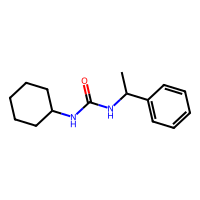
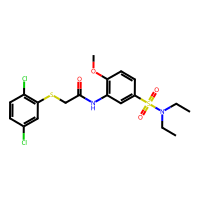
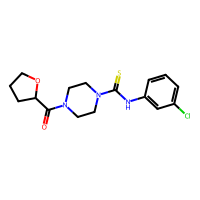
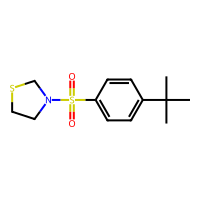
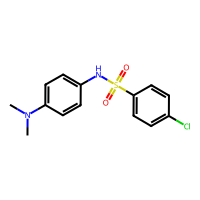
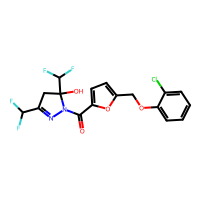
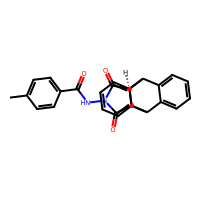
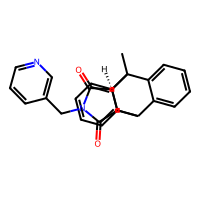
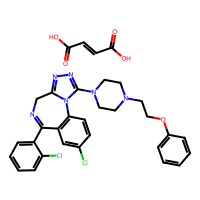
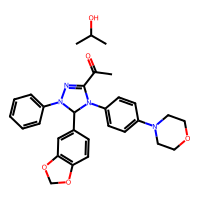

In [ ]:
#agrego smiles a la tabla
PandasTools.AddMoleculeColumnToFrame(df_dengue, smilesCol='PUBCHEM_EXT_DATASOURCE_SMILES')
df_dengue

In [ ]:
from rdkit.Chem import inchi

#funcion para evitar duplicados usando inchikeys
def remover_duplicados_por_inchikey(df):
    """
    Agrega columna InChIKey al DataFrame y elimina moléculas duplicadas según ese identificador.

    Parámetros:
        df (pd.DataFrame): DataFrame que contiene una columna con SMILES.

    Retorna:
        df_sin_duplicados (pd.DataFrame): Nuevo DataFrame sin duplicados por InChIKey.
    """
    df = df.copy()

    # Obtener InChIKey (NaN si falla)
    df['InChIKey'] = df['ROMol'].apply(lambda mol: inchi.MolToInchiKey(mol) if mol else None)

    # Eliminar duplicados por InChIKey
    df_sin_duplicados = df.drop_duplicates(subset='InChIKey')

    # (Eliminar columnas auxiliares
    df_sin_duplicados = df_sin_duplicados.drop(columns=['InChIKey'])

    return df_sin_duplicados

In [ ]:
# aplico la funcion a mi df
df_dengue = remover_duplicados_por_inchikey (df_dengue)

In [ ]:
df_dengue

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,ROMol
2,1,22415874.0,2930832.0,CC(C1=CC=CC=C1)NC(=O)NC2CCCCC2,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406a40>
3,2,22404652.0,3376686.0,CCN(CC)S(=O)(=O)C1=CC(=C(C=C1)OC)NC(=O)CSC2=C(...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406960>
4,3,17432810.0,2909436.0,C1CC(OC1)C(=O)N2CCN(CC2)C(=S)NC3=CC(=CC=C3)Cl,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406ab0>
5,4,22402092.0,1236385.0,CC(C)(C)C1=CC=C(C=C1)S(=O)(=O)N2CCSC2,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406b20>
6,5,17508350.0,519685.0,CN(C)C1=CC=C(C=C1)NS(=O)(=O)C2=CC=C(C=C2)Cl,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406b90>
...,...,...,...,...,...,...
10237,10236,22413218.0,5178810.0,C1C(=NN(C1(C(F)F)O)C(=O)C2=CC=C(O2)COC3=CC=CC=...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7eb65cf90>
10238,10237,17504335.0,12004494.0,CC1=CC=C(C=C1)C(=O)NN2C(=O)[C@@H]3C(C2=O)C4C5=...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7eb65d000>
10239,10238,17506199.0,12004654.0,CC12[C@H]3C(C(C4=CC=CC=C41)C5=CC=CC=C25)C(=O)N...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7eb65d070>
10240,10239,17415853.0,11958904.0,C1CN(CCN1CCOC2=CC=CC=C2)C3=NN=C4N3C5=C(C=C(C=C...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7eb65d0e0>


In [ ]:
#borro filas que no contengan datos de mi target
df_dengue = df_dengue.dropna(subset=['PUBCHEM_ACTIVITY_OUTCOME'])

In [ ]:
df_dengue

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,ROMol
2,1,22415874.0,2930832.0,CC(C1=CC=CC=C1)NC(=O)NC2CCCCC2,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406a40>
3,2,22404652.0,3376686.0,CCN(CC)S(=O)(=O)C1=CC(=C(C=C1)OC)NC(=O)CSC2=C(...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406960>
4,3,17432810.0,2909436.0,C1CC(OC1)C(=O)N2CCN(CC2)C(=S)NC3=CC(=CC=C3)Cl,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406ab0>
5,4,22402092.0,1236385.0,CC(C)(C)C1=CC=C(C=C1)S(=O)(=O)N2CCSC2,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406b20>
6,5,17508350.0,519685.0,CN(C)C1=CC=C(C=C1)NS(=O)(=O)C2=CC=C(C=C2)Cl,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406b90>
...,...,...,...,...,...,...
10237,10236,22413218.0,5178810.0,C1C(=NN(C1(C(F)F)O)C(=O)C2=CC=C(O2)COC3=CC=CC=...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7eb65cf90>
10238,10237,17504335.0,12004494.0,CC1=CC=C(C=C1)C(=O)NN2C(=O)[C@@H]3C(C2=O)C4C5=...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7eb65d000>
10239,10238,17506199.0,12004654.0,CC12[C@H]3C(C(C4=CC=CC=C41)C5=CC=CC=C25)C(=O)N...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7eb65d070>
10240,10239,17415853.0,11958904.0,C1CN(CCN1CCOC2=CC=CC=C2)C3=NN=C4N3C5=C(C=C(C=C...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7eb65d0e0>


#Análisis exploratorio de datos

#Descriptores

In [ ]:
from rdkit.Chem import Lipinski

#funcion para obtener descriptores
def agregar_descriptores(df, mol_col='ROMol'):
    df = df.copy()
    df['MolWt'] = df[mol_col].apply(Descriptors.MolWt)
    df['LogP'] = df[mol_col].apply(Descriptors.MolLogP)
    df['NumHDonors'] = df[mol_col].apply(Lipinski.NumHDonors)
    df['NumHAcceptors'] = df[mol_col].apply(Lipinski.NumHAcceptors)
    df['TPSA'] = df[mol_col].apply(rdMolDescriptors.CalcTPSA)
    df['NumRotatableBonds'] = df[mol_col].apply(Lipinski.NumRotatableBonds)
    df['RingCount'] = df[mol_col].apply(rdMolDescriptors.CalcNumRings)

    # Atomos aromáticos (proporción)
    df['atomos_aromaticos_proportion'] = df[mol_col].apply(
        lambda mol: len([a for a in mol.GetAtoms() if a.GetIsAromatic()]) / mol.GetNumAtoms()
        if mol and mol.GetNumAtoms() > 0 else None
    )

    # Proporción de átomos que NO son carbono
    df['non_Carbono_proportion'] = df[mol_col].apply(
        lambda mol: len([a for a in mol.GetAtoms() if a.GetSymbol() != 'C']) / mol.GetNumAtoms()
        if mol and mol.GetNumAtoms() > 0 else None
    )

    return df

In [ ]:
#Se lo aplico a mi df
df_dengue = agregar_descriptores(df_dengue)

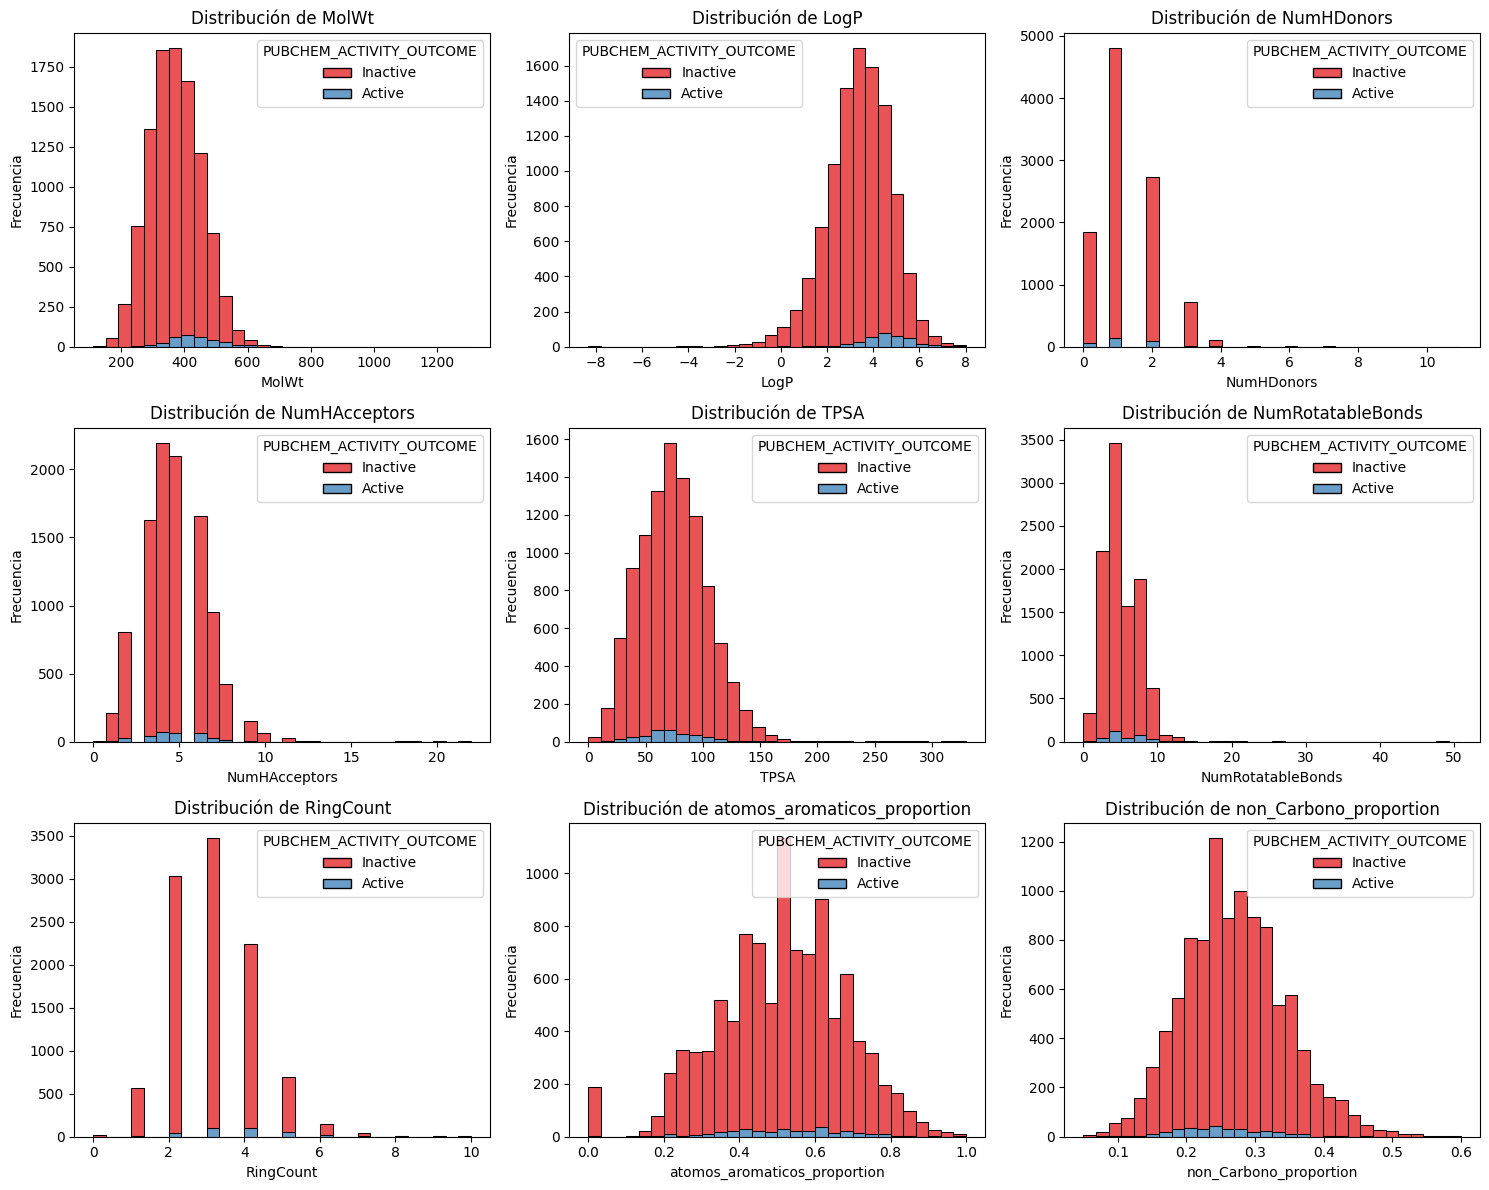

In [ ]:
#análisis d la distribucion de las características según si son activos o inactivos
columnas = ['MolWt',	'LogP',	'NumHDonors',	'NumHAcceptors',	'TPSA',	'NumRotatableBonds',	'RingCount', 'atomos_aromaticos_proportion',	'non_Carbono_proportion']

n = len(columnas)
ncols = 3
nrows = (n + ncols - 1) // ncols

plt.figure(figsize=(5 * ncols, 4 * nrows))

for i, col in enumerate(columnas, 1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(
        data=df_dengue,
        x=col,
        hue='PUBCHEM_ACTIVITY_OUTCOME',
        bins=30,
        multiple='stack',
        palette='Set1'
    )
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

#Clasificamos en activos para obtener una mejor visualización.

In [ ]:
#clasificamos en inactivos para ver si podemos definir un umbral de forma intuitiva
df_activos = df_dengue [df_dengue[('PUBCHEM_ACTIVITY_OUTCOME')]=='Active']

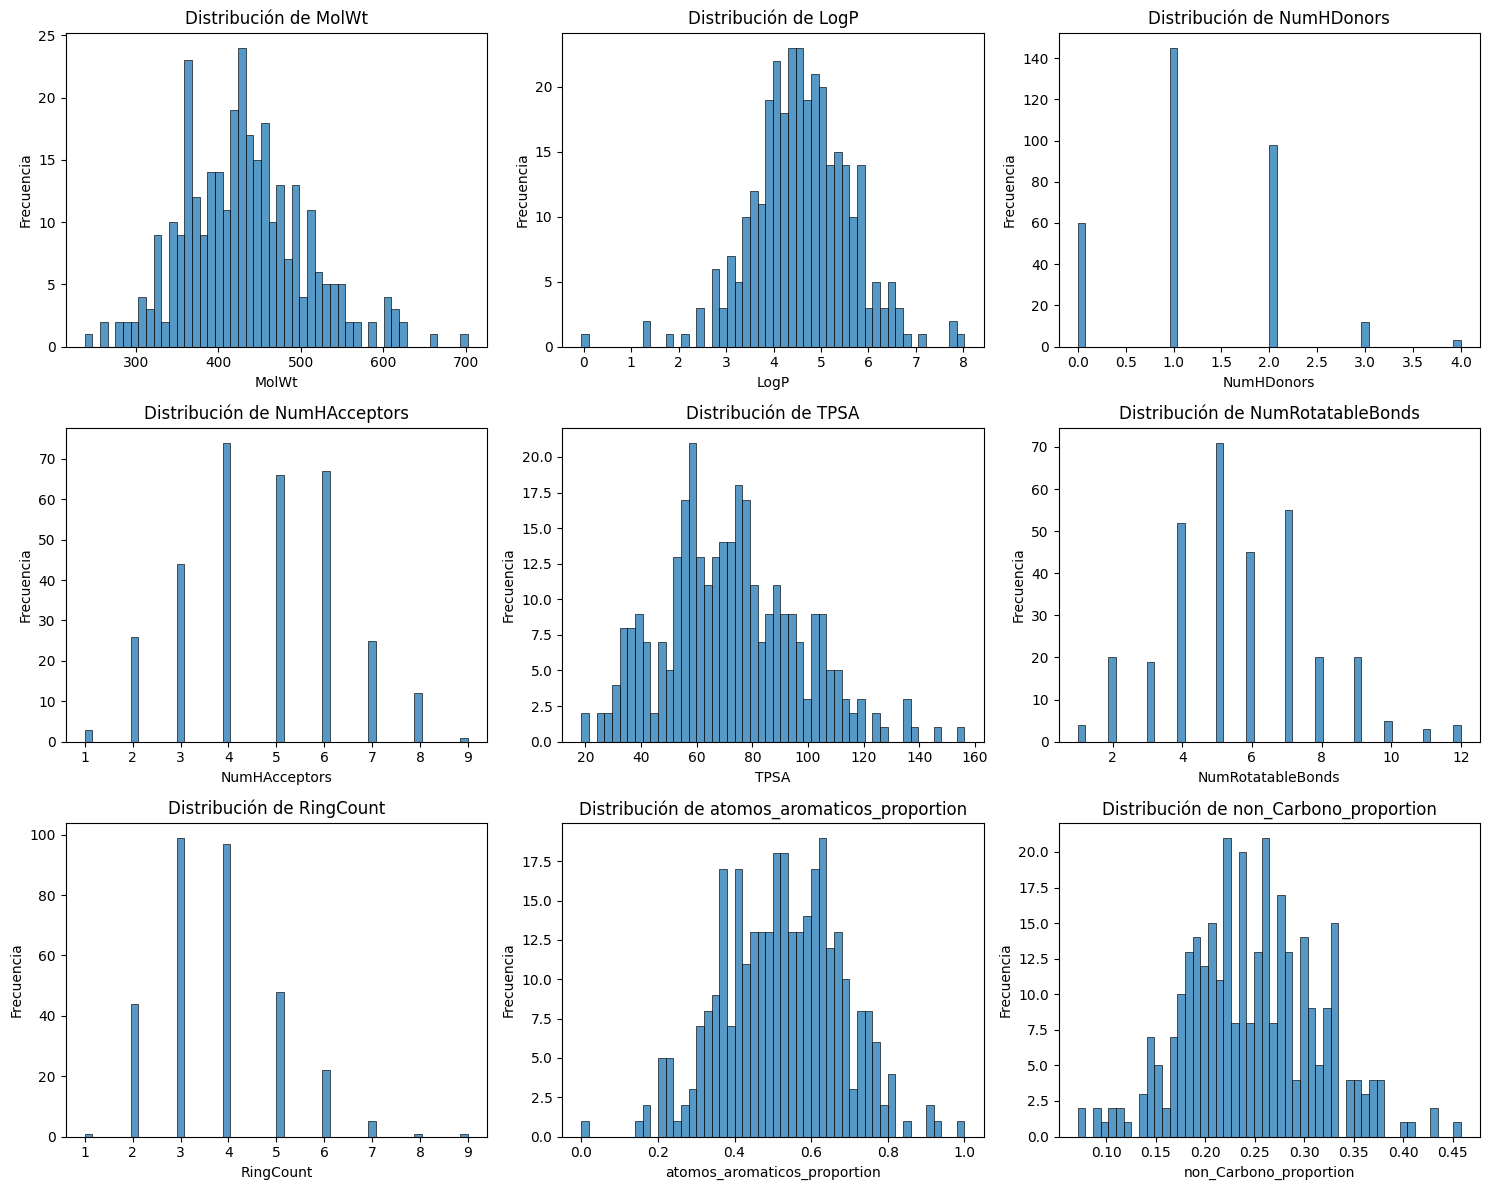

In [ ]:
#plot de nuevo
columnas = ['MolWt',	'LogP',	'NumHDonors',	'NumHAcceptors',	'TPSA',	'NumRotatableBonds',	'RingCount', 'atomos_aromaticos_proportion',	'non_Carbono_proportion']

n = len(columnas)
ncols = 3
nrows = (n + ncols - 1) // ncols

plt.figure(figsize=(5 * ncols, 4 * nrows))

for i, col in enumerate(columnas, 1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(
        data=df_activos,
        x=col,
        # hue='PUBCHEM_ACTIVITY_OUTCOME',
        bins=50,
        multiple='stack',  # o 'stack' o 'layer'
        palette='Set1'
    )
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

#Propiedades fisicoquimicas

#Lipinski

In [ ]:
# Hacer una copia del DataFrame original
df_dengue_fq = df_dengue.copy()

# Aplicar la regla de Lipinski fila por fila
def cumple_lipinski(row):
    return (
        row['MolWt'] <= 500 and
        row['LogP'] <= 5 and
        row['NumHDonors'] <= 5 and
        row['NumHAcceptors'] <= 10
    )

df_dengue_fq['lipinski'] = df_dengue_fq.apply(cumple_lipinski, axis=1)


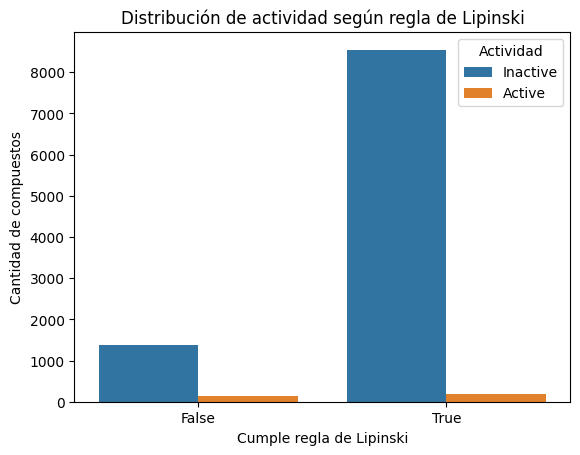

In [ ]:

# Gráfico de barras agrupadas
sns.countplot(data=df_dengue_fq, x='lipinski', hue='PUBCHEM_ACTIVITY_OUTCOME')
plt.title('Distribución de actividad según regla de Lipinski')
plt.xlabel('Cumple regla de Lipinski')
plt.ylabel('Cantidad de compuestos')
plt.legend(title='Actividad')
plt.show()


#Regla de los 3

In [ ]:
def cumple_regla_3(row):
    return (
        row['MolWt'] <= 300 and
        row['LogP'] <= 3 and
        row['NumHDonors'] <= 3 and
        row['NumHAcceptors'] <= 3
    )

df_dengue_fq['regla3'] = df_dengue_fq.apply(cumple_regla_3, axis=1)


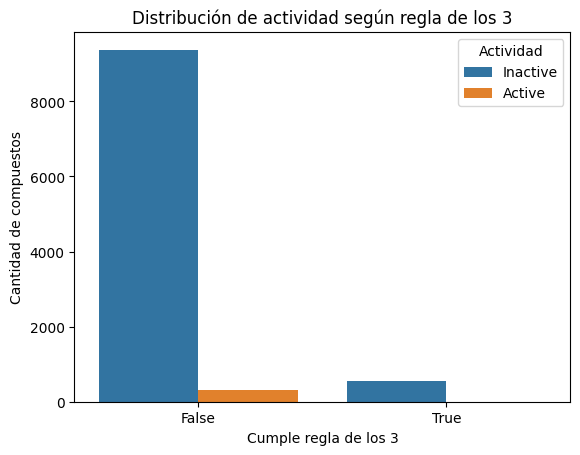

In [ ]:
# Gráfico de barras agrupadas
sns.countplot(data=df_dengue_fq, x='regla3', hue='PUBCHEM_ACTIVITY_OUTCOME')
plt.title('Distribución de actividad según regla de los 3')
plt.xlabel('Cumple regla de los 3')
plt.ylabel('Cantidad de compuestos')
plt.legend(title='Actividad')
plt.show()

# PAINS

In [ ]:
from rdkit.Chem import FilterCatalog
#optamos por usar chem en vez de adme por la eficacia

params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_A)
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_B)
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_C)

catalog = FilterCatalog.FilterCatalog(params)

def es_pains(mol):
    if mol is None:
        return False
    return catalog.HasMatch(mol)

df_dengue_fq['pains'] = df_dengue_fq['ROMol'].apply(es_pains)


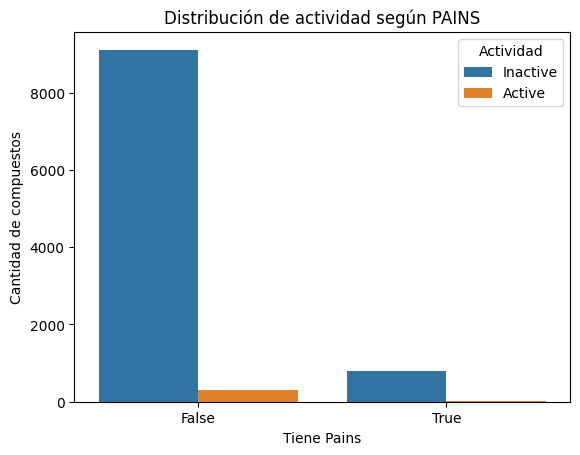

In [ ]:
# Gráfico de barras agrupadas
sns.countplot(data=df_dengue_fq, x='pains', hue='PUBCHEM_ACTIVITY_OUTCOME')
plt.title('Distribución de actividad según PAINS')
plt.xlabel('Tiene Pains')
plt.ylabel('Cantidad de compuestos')
plt.legend(title='Actividad')
plt.show()

In [ ]:
df_dengue

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,ROMol,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,RingCount,atomos_aromaticos_proportion,non_Carbono_proportion
2,1,22415874.0,2930832.0,CC(C1=CC=CC=C1)NC(=O)NC2CCCCC2,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406a40>,246.354,3.37950,2,1,41.13,3,2,0.333333,0.166667
3,2,22404652.0,3376686.0,CCN(CC)S(=O)(=O)C1=CC(=C(C=C1)OC)NC(=O)CSC2=C(...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406960>,477.435,4.76330,1,5,75.71,9,2,0.413793,0.344828
4,3,17432810.0,2909436.0,C1CC(OC1)C(=O)N2CCN(CC2)C(=S)NC3=CC(=CC=C3)Cl,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406ab0>,353.875,2.36000,1,3,44.81,2,3,0.260870,0.304348
5,4,22402092.0,1236385.0,CC(C)(C)C1=CC=C(C=C1)S(=O)(=O)N2CCSC2,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406b20>,285.434,2.67910,0,3,37.38,2,2,0.333333,0.277778
6,5,17508350.0,519685.0,CN(C)C1=CC=C(C=C1)NS(=O)(=O)C2=CC=C(C=C2)Cl,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7e8406b90>,310.806,3.20680,1,3,49.41,4,2,0.600000,0.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10237,10236,22413218.0,5178810.0,C1C(=NN(C1(C(F)F)O)C(=O)C2=CC=C(O2)COC3=CC=CC=...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7eb65cf90>,420.746,3.93270,1,5,75.27,6,3,0.392857,0.392857
10238,10237,17504335.0,12004494.0,CC1=CC=C(C=C1)C(=O)NN2C(=O)[C@@H]3C(C2=O)C4C5=...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7eb65d000>,408.457,3.53202,1,3,66.48,2,7,0.580645,0.161290
10239,10238,17506199.0,12004654.0,CC12[C@H]3C(C(C4=CC=CC=C41)C5=CC=CC=C25)C(=O)N...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7eb65d070>,380.447,3.64790,0,3,50.27,2,7,0.620690,0.137931
10240,10239,17415853.0,11958904.0,C1CN(CCN1CCOC2=CC=CC=C2)C3=NN=C4N3C5=C(C=C(C=C...,Inactive,<rdkit.Chem.rdchem.Mol object at 0x7fa7eb65d0e0>,649.535,4.83790,2,9,133.38,8,6,0.511111,0.288889


#Modelo KKN con las variables TPSA y LogP
Recall es nuestra métrica elegida. Queremos tomar la mayor cantidad de compuestos activos (verdaderos postivos), incluso si hay inactivos predecidos como activos (falsos positivos).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
!pip install mglearn
import mglearn
#definimos x e y
X = df_dengue.loc[:,['NumRotatableBonds', 'TPSA']]
y = df_dengue.loc[:,'PUBCHEM_ACTIVITY_OUTCOME']

# dividir en training y testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=0)

# Estandarizar los datos
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# definir el algoritmo
clf = KNeighborsClassifier(n_neighbors=3)
# entrenar el algoritmo
clf.fit(X_train_scaled, y_train)
# Aplico el model al set de evaluación
print("Test set predictions: {}".format(clf.predict(X_test_scaled)))
# Evaluo el modelo
print("Test set accuracy: {:.2f}".format(clf.score(X_test_scaled, y_test)))

Test set predictions: ['Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive' 'Inactive'
 'Inactive' 'Inactive' 'Inactive' 'Inact

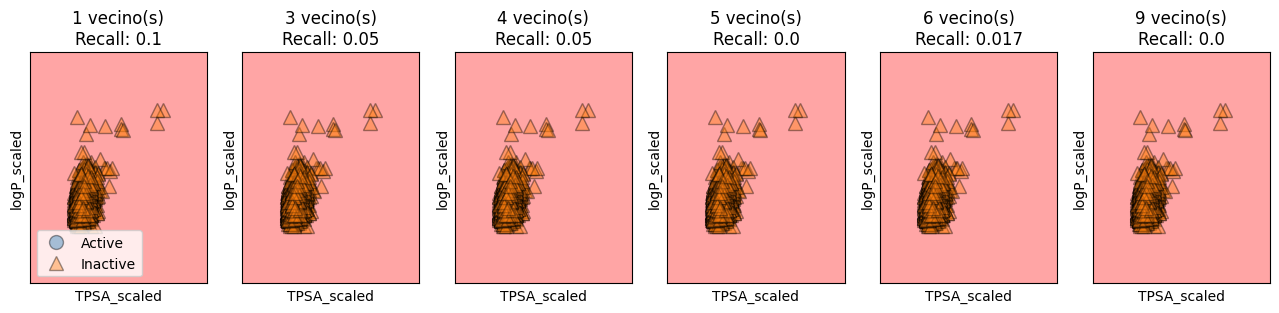

In [ ]:
from sklearn.metrics import recall_score

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for n_neighbors, ax in zip([1, 3, 4, 5, 6, 9], axes):
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    rec = recall_score(y_test, y_pred, pos_label='Active')

    mglearn.plots.plot_2d_separator(clf, X_train_scaled, fill=True, eps=0.5, ax=ax, alpha=.4)
    mglearn.discrete_scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], y_train, ax=ax, alpha=.4)

    ax.set_title(f'{n_neighbors} vecino(s)\nRecall: {round(rec, 3)}')
    ax.set_xlabel("TPSA_scaled")
    ax.set_ylabel("logP_scaled")

axes[0].legend(loc=3)

#Modelo RandomForest con descriptores

Recall train (clase Active): 0.724
Recall test  (clase Active): 0.044


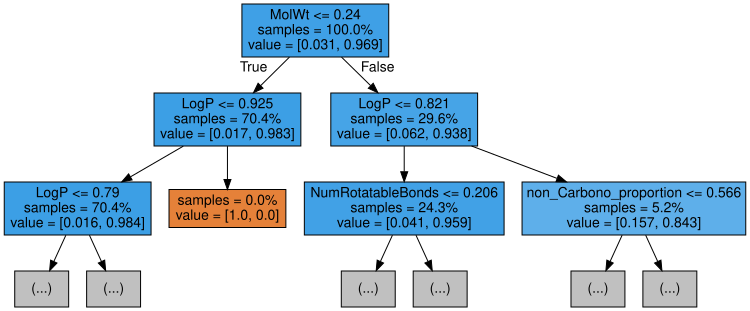

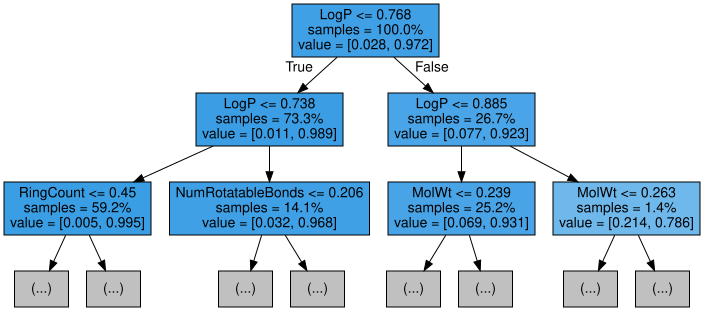

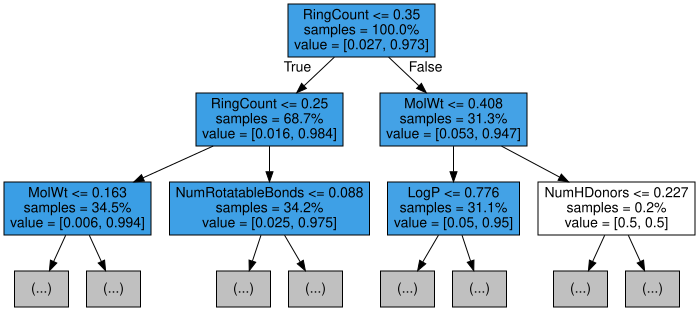

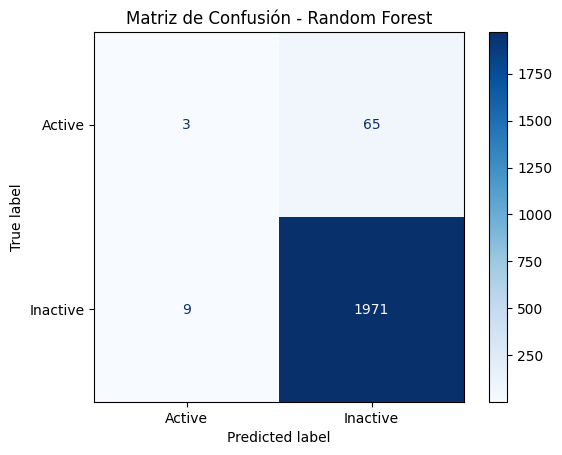

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import export_graphviz
from IPython.display import display
import graphviz

# 1. Definir X e y
X = df_dengue.loc[:, ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors',
                      'TPSA', 'NumRotatableBonds', 'RingCount',
                      'atomos_aromaticos_proportion', 'non_Carbono_proportion']]
y = df_dengue['PUBCHEM_ACTIVITY_OUTCOME']

# 2. Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Escalar
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entrenar Random Forest
rf = RandomForestClassifier(n_estimators=5, random_state=42)
rf.fit(X_train_scaled, y_train)

# 5. Predecir en test y train
y_test_pred = rf.predict(X_test_scaled)
y_train_pred = rf.predict(X_train_scaled)

# 6. Calcular recall en train y test para la clase 'Active'
recall_train = recall_score(y_train, y_train_pred, pos_label='Active')
recall_test = recall_score(y_test, y_test_pred, pos_label='Active')
print(f"Recall train (clase Active): {recall_train:.3f}")
print(f"Recall test  (clase Active): {recall_test:.3f}")

# 7. Graficar primeros 3 árboles (max_depth=2)
for i in range(min(3, len(rf.estimators_))):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X.columns,
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

# 8. Matriz de confusión en test
cm = confusion_matrix(y_test, y_test_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Random Forest")
plt.show()


#Modelo RandomForest con Fingerprints

Recall train (clase Active): 0.716
Recall test  (clase Active): 0.059


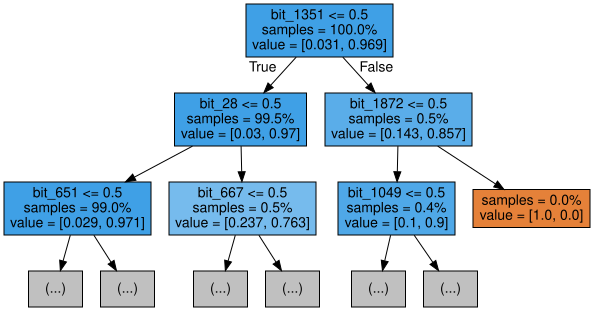

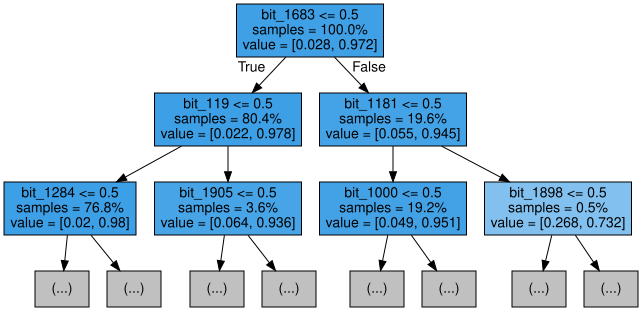

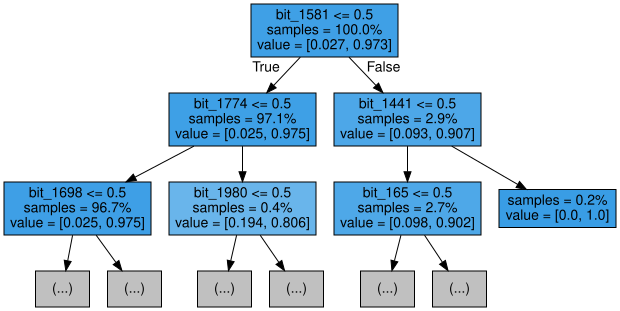

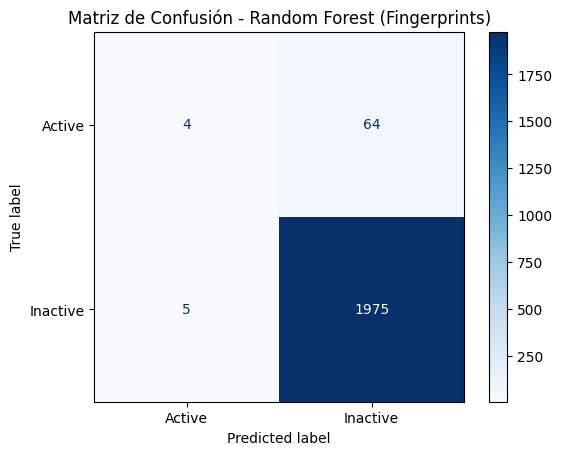

In [ ]:
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs.cDataStructs import ConvertToNumpyArray

# Generador de fingerprints Morgan ya que fingerprints de Chem no puede hacerlo
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# 2. Fingerprints + target
df_dengue = df_dengue.reset_index(drop=True)
fps_np = []
y_clean = []

for i, mol in enumerate(df_dengue['ROMol']):
    try:
        fp = gen.GetFingerprint(mol)
        arr = np.zeros((2048,), dtype=int)
        ConvertToNumpyArray(fp, arr)
        fps_np.append(arr)
        y_clean.append(df_dengue.loc[i, 'PUBCHEM_ACTIVITY_OUTCOME'])
    except Exception as e:
        print(f"⚠️ Error en índice {i}: {e}") #excepxiones porque usamos datasets con ids desordenados

#arrays
X = np.stack(fps_np)
y = np.array(y_clean)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# modelo Random Forest
rf = RandomForestClassifier(n_estimators=5, random_state=42)
rf.fit(X_train, y_train)

# predicción
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# recall
recall_train = recall_score(y_train, y_train_pred, pos_label='Active')
recall_test = recall_score(y_test, y_test_pred, pos_label='Active')
print(f"Recall train (clase Active): {recall_train:.3f}")
print(f"Recall test  (clase Active): {recall_test:.3f}")

# visualización de árboles
for i in range(min(3, len(rf.estimators_))):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=[f"bit_{j}" for j in range(X.shape[1])],
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

# 9. Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Random Forest (Fingerprints)")
plt.show()

#Prueba del modelo en FDA

In [ ]:
pip install chembl_webresource_client

In [ ]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule

# fase clínica 4 (aprobados)
query = molecule.filter(max_phase=4).only(['molecule_chembl_id', 'pref_name', 'molecule_structures'])

# moléculas con SMILES válidos
records = []
for mol in query:
    mol_struct = mol.get('molecule_structures')
    if mol_struct and mol_struct.get('canonical_smiles'):
        records.append({
            'chembl_id': mol['molecule_chembl_id'],
            'name': mol.get('pref_name', ''),
            'smiles': mol_struct['canonical_smiles']
        })
df_fda = pd.DataFrame(records)

In [ ]:

from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs.cDataStructs import ConvertToNumpyArray

# convertir SMILES a ROMol
df_fda['ROMol'] = df_fda['smiles'].apply(lambda x: Chem.MolFromSmiles(x))
df_fda = df_fda[df_fda['ROMol'].notnull()].reset_index(drop=True)

#6enerar fingerprints Morgan
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

fps_fda = []
for mol in df_fda['ROMol']:
    fp = gen.GetFingerprint(mol)
    arr = np.zeros((2048,), dtype=int)
    ConvertToNumpyArray(fp, arr)
    fps_fda.append(arr)

X_fda = np.stack(fps_fda)

# predecir
y_fda_pred = rf.predict(X_fda)
df_fda['Predicted'] = y_fda_pred

# métrica: proporción de compuestos FDA predichos como 'Active'
total = len(df_fda)
n_active = (df_fda['Predicted'] == 'Active').sum()
porcentaje = n_active / total

print(f"De {total} compuestos FDA, {n_active} fueron predichos como 'Active' ({porcentaje:.2%})")


[01:17:52] WARNING: not removing hydrogen atom without neighbors
[01:17:52] WARNING: not removing hydrogen atom without neighbors
[01:17:52] WARNING: not removing hydrogen atom without neighbors
[01:17:52] WARNING: not removing hydrogen atom without neighbors
[01:17:53] WARNING: not removing hydrogen atom without neighbors
[01:17:53] WARNING: not removing hydrogen atom without neighbors


De 3594 compuestos FDA, 16 fueron predichos como 'Active' (0.45%)



# Resultados

## 1. Evaluación del modelo seleccionado (Random Forest con fingerprints)
- Recall en test: 0.059
- Matriz de confusión:
  - 4 verdaderos positivos
  - 5 falsos positivos
  - 64 falsos negativos
  - 1975 verdaderos negativos


## 2. Prueba sobre compuestos FDA
- Se evaluaron 3594 compuestos.
- El modelo predijo como “Active” a 15 de ellos (~0,5%).
- Algunos nombres:

**Pirilamina:** Antihistamínico de primera generación, se usa para aliviar síntomas de alergias como estornudos, secreción nasal y picazón.

**Tripelenamina:** Otro antagonista H1 usado en el tratamiento de asma, urticaria, fiebre del heno y rinitis. También tiene aplicaciones veterinarias.

**tonzonios (varios):** Compuesto con propiedades tensioactivas, usado en gotas óticas y nasales para mejorar la penetración de medicamentos.

**cefiderocol:** Antibiótico de amplio espectro, utilizado en infecciones urinarias complicadas y neumonía hospitalaria, especialmente en casos con bacterias multirresistentes.

**Hidrocloruro de vancomicina:** Antibacterial obtenido de Streptomyces orientalis. única opción de tratamiento oral con líquido oral de vancomicina aprobada por la FDA disponible para el tratamiento de la diarrea asociada de Clostridium difficile y la enterocolitis causada por Staphylococcus aureus


In [ ]:
# filtrar compuestos predichos como 'Active'
activos = df_fda[df_fda['Predicted'] == 'Active']

print(f"De {total} compuestos FDA, {n_active} fueron predichos como 'Active' ({porcentaje:.2%})")
print("\nLista de compuestos predichos como 'Active' (SMILES):")
for i, row in activos.iterrows():
    print(f"Índice {i}: {row['smiles']}")


De 3594 compuestos FDA, 16 fueron predichos como 'Active' (0.45%)

Lista de compuestos predichos como 'Active' (SMILES):
Índice 173: COc1ccc(CN(CCN(C)C)c2ccccn2)cc1
Índice 594: CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=O)C(=O)N[C@H]2C(=O)N[C@H]3C(=O)N[C@H](C(=O)N[C@H](C(=O)O)c4cc(O)cc(O)c4-c4cc3ccc4O)[C@H](O)c3ccc(c(Cl)c3)Oc3cc2cc(c3O[C@@H]2O[C@H](CO)[C@@H](O)[C@H](O)[C@H]2O[C@H]2C[C@](C)(N)[C@H](O)[C@H](C)O2)Oc2ccc(cc2Cl)[C@H]1O
Índice 958: CN(C)CCN(Cc1ccccc1)c1ccccn1
Índice 1488: CCCCCCCCCCNCCN[C@@]1(C)C[C@H](O[C@H]2[C@H](Oc3c4cc5cc3Oc3ccc(cc3Cl)[C@@H](O)[C@@H](NC(=O)[C@@H](CC(C)C)NC)C(=O)N[C@@H](CC(N)=O)C(=O)N[C@H]5C(=O)N[C@H]3C(=O)N[C@H](C(=O)N[C@H](C(=O)O)c5cc(O)c(CNCP(=O)(O)O)c(O)c5-c5cc3ccc5O)[C@H](O)c3ccc(c(Cl)c3)O4)O[C@H](CO)[C@@H](O)[C@@H]2O)O[C@@H](C)[C@H]1O
Índice 1793: CN(C)CCN(Cc1ccccc1)c1ccccn1.Cl
Índice 1905: CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=O)C(=O)N[C@H]2C(=O)N[C@H]3C(=O)N[C@H](C(=O)N[C@H](C(=O)O)c4cc(O)cc(O)c4-c4cc3ccc4O)[C@H](O)c3ccc(c(Cl)c3)Oc3cc2cc

#Conclusiones
El modelo logró captar ciertos patrones químicos que están relacionados con la actividad contra el dengue, pero como tenemos más moléculas inactivas que activas y la química es compleja, el recall en datos nuevos no es tan alto como quisiéramos.

Los fingerprints son súper útiles porque representan bien la estructura de las moléculas, pero para que el modelo no se “aprenda de memoria” los datos (overfitting) necesitamos ajustar mejor los parámetros o conseguir más datos.

Usar validación cruzada y probar distintos parámetros es clave para que el modelo generalice mejor y no solo funcione bien con el dataset con el que entrenamos.

Cuando probamos el modelo con los compuestos aprobados por FDA, vimos que se comporta de forma coherente y podría servir para hacer screening virtual de nuevos fármacos,pero es un primer paso o una guía.

Para seguir mejorando, podemos balancear el dataset con  otras técnicas para que el modelo vea más ejemplos activos, y también bajar la cantidad de activos tomados como inactivos.